In [97]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [98]:
import pandas as pd
import numpy as np
import re

In [99]:
df=pd.read_csv("/content/drive/MyDrive/used_cars.csv")
df.head(5)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [100]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [101]:
df.isnull().sum()


,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,221
engine,221


In [102]:
df.duplicated().sum()

np.int64(1202)

In [103]:
df=df.drop_duplicates().reset_index(drop=True)

In [104]:
df=df.drop(columns=['torque','name'])

In [105]:

df['mileage']=df['mileage'].str.extract(r'([\d.]+)').astype('float')
df['engine']=df['engine'].str.extract(r'([\d.]+)').astype('float')
df['max_power']=df['max_power'].str.extract(r'([\d.]+)').astype('float')


In [106]:
df[['mileage', 'engine', 'max_power']].describe()

,mileage,engine,max_power
count,6718.00000,6718.000000,6720.000000
mean,19.46531,1430.891337,87.726919
std,4.04915,493.493277,31.771619
min,0.00000,624.000000,0.000000
25%,16.80000,1197.000000,67.100000
50%,19.44000,1248.000000,81.830000
75%,22.50000,1498.000000,100.000000
max,42.00000,3604.000000,400.000000


In [107]:
df.loc[df['mileage']==0,'mileage']=np.nan
df.loc[df['max_power']==0,'max_power']=np.nan
#or df['mileage'] = df['mileage'].replace(0, np.nan)

In [108]:
df['mileage']=df['mileage'].fillna(df['mileage'].mean())
df['max_power']=df['max_power'].fillna(df['max_power'].mean())
df['engine']=df['engine'].fillna(df['engine'].median())
df['seats']=df['seats'].fillna(df['seats'].mode()[0])

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6926 entries, 0 to 6925
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           6926 non-null   int64  
 1   selling_price  6926 non-null   int64  
 2   km_driven      6926 non-null   int64  
 3   fuel           6926 non-null   object 
 4   seller_type    6926 non-null   object 
 5   transmission   6926 non-null   object 
 6   owner          6926 non-null   object 
 7   mileage        6926 non-null   float64
 8   engine         6926 non-null   float64
 9   max_power      6926 non-null   float64
 10  seats          6926 non-null   float64
dtypes: float64(4), int64(3), object(4)
memory usage: 595.3+ KB


In [110]:
change_columns=['selling_price','km_driven','mileage','engine','max_power']
def detect_outliers(df,cols,factor=1.5):
    outlier_mask=pd.Series(False,index=df.index)
    for col in cols:
        q1=df[col].quantile(0.25)
        q3=df[col].quantile(0.75)
        iqr=q3-q1
        lower_bound=q1-factor*iqr
        upper_bound=q3+factor*iqr
        outlier_cols=(df[col]<lower_bound)|(df[col]>upper_bound)
        outlier_mask=outlier_mask|outlier_cols
    return  outlier_mask
outliers=detect_outliers(df,change_columns)
print(f'number of outliers record: {outliers.sum()}')


number of outliers record: 1345


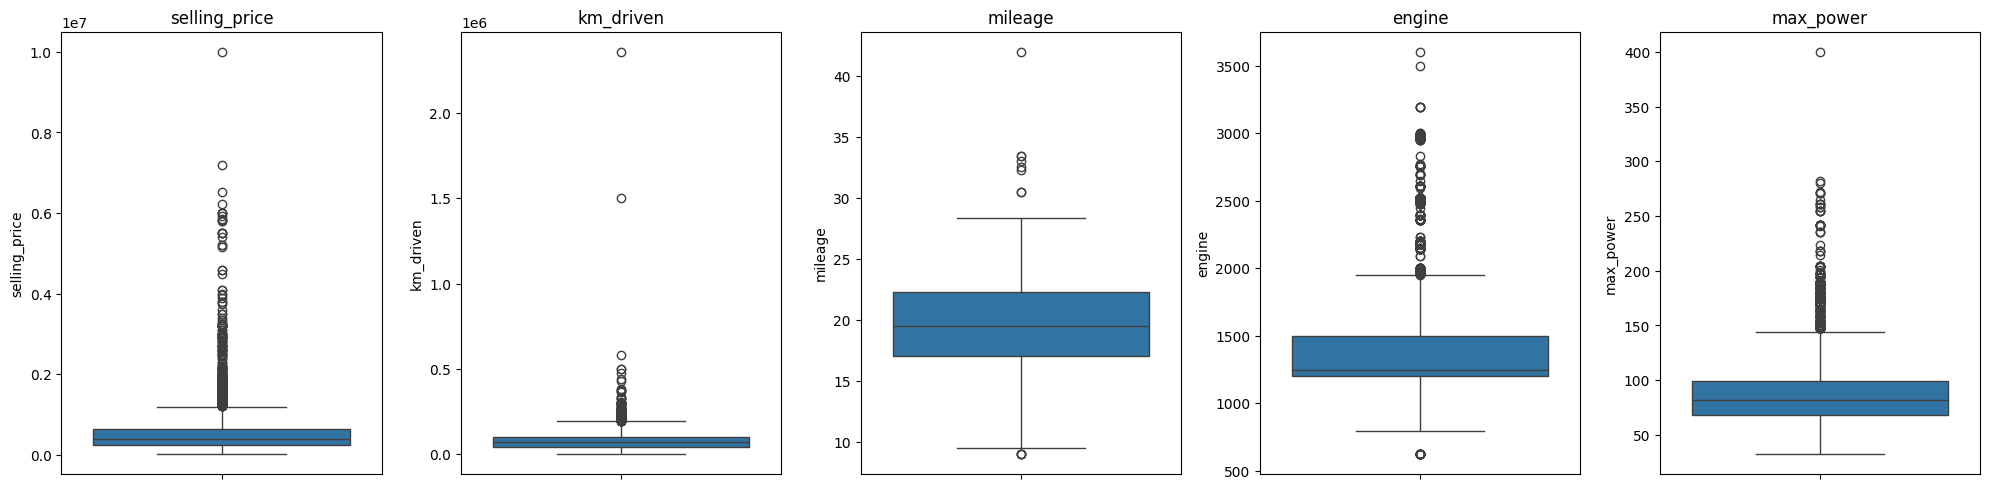

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=1, ncols=len(change_columns), figsize=(20, 5))

for i, col in enumerate(change_columns):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

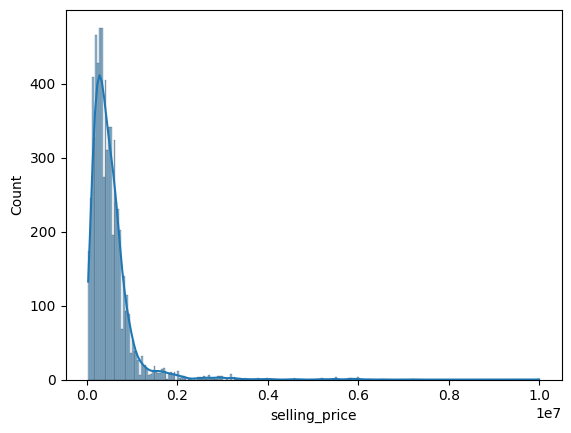

In [112]:
sns.histplot(df['selling_price'], kde=True)
plt.show()

In [113]:
print("Mean:", df['selling_price'].mean())
print("Median:", df['selling_price'].median())

Mean: 517270.6784579844
Median: 400000.0


In [114]:
for col in ['km_driven', 'mileage']:
    print(col, "skew:", df[col].skew())

km_driven skew: 11.758425539599084
mileage skew: 0.05499948551059012


In [115]:
df['selling_price'] = np.log1p(df['selling_price'])
df['engine'] = np.log1p(df['engine'])
df['max_power'] = np.log1p(df['max_power'])
df['km_driven'] = np.log1p(df['km_driven'])

In [116]:
from sklearn.preprocessing import MinMaxScaler

features = ['selling_price', 'engine', 'max_power', 'km_driven', 'mileage']
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

In [117]:
df.select_dtypes(include='object')

,fuel,seller_type,transmission,owner
0,Diesel,Individual,Manual,First Owner
1,Diesel,Individual,Manual,Second Owner
2,Petrol,Individual,Manual,Third Owner
3,Diesel,Individual,Manual,First Owner
4,Petrol,Individual,Manual,First Owner
...,...,...,...,...
6921,Petrol,Individual,Manual,Second Owner
6922,Diesel,Individual,Manual,Second Owner
6923,Petrol,Individual,Manual,First Owner
6924,Diesel,Individual,Manual,Fourth & Above Owner


In [118]:
for col in ['fuel', 'seller_type', 'transmission', 'owner']:
  print(col, ":", df[col].nunique())
  print(df[col].unique())
  print()


fuel : 4
['Diesel' 'Petrol' 'LPG' 'CNG']

seller_type : 3
['Individual' 'Dealer' 'Trustmark Dealer']

transmission : 2
['Manual' 'Automatic']

owner : 5
['First Owner' 'Second Owner' 'Third Owner' 'Fourth & Above Owner'
 'Test Drive Car']



In [119]:
categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner']

df = pd.get_dummies(df, columns=categorical_cols)

In [120]:
df.head()


,year,selling_price,km_driven,mileage,engine,max_power,seats,fuel_CNG,fuel_Diesel,fuel_LPG,...,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Automatic,transmission_Manual,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2014,0.466171,0.800702,0.436364,0.395102,0.322226,5.0,False,True,False,...,False,True,False,False,True,True,False,False,False,False
1,2014,0.432475,0.786921,0.367879,0.499223,0.456405,5.0,False,True,False,...,False,True,False,False,True,False,False,True,False,False
2,2006,0.285998,0.797946,0.263636,0.498843,0.343233,5.0,False,False,False,...,False,True,False,False,True,False,False,False,False,True
3,2010,0.346851,0.790976,0.424242,0.459008,0.400404,5.0,False,True,False,...,False,True,False,False,True,True,False,False,False,False
4,2007,0.252420,0.786921,0.215152,0.417501,0.392327,5.0,False,False,False,...,False,True,False,False,True,True,False,False,False,False


In [121]:
df[df.select_dtypes(include='bool').columns] = df.select_dtypes(include='bool').astype(int)

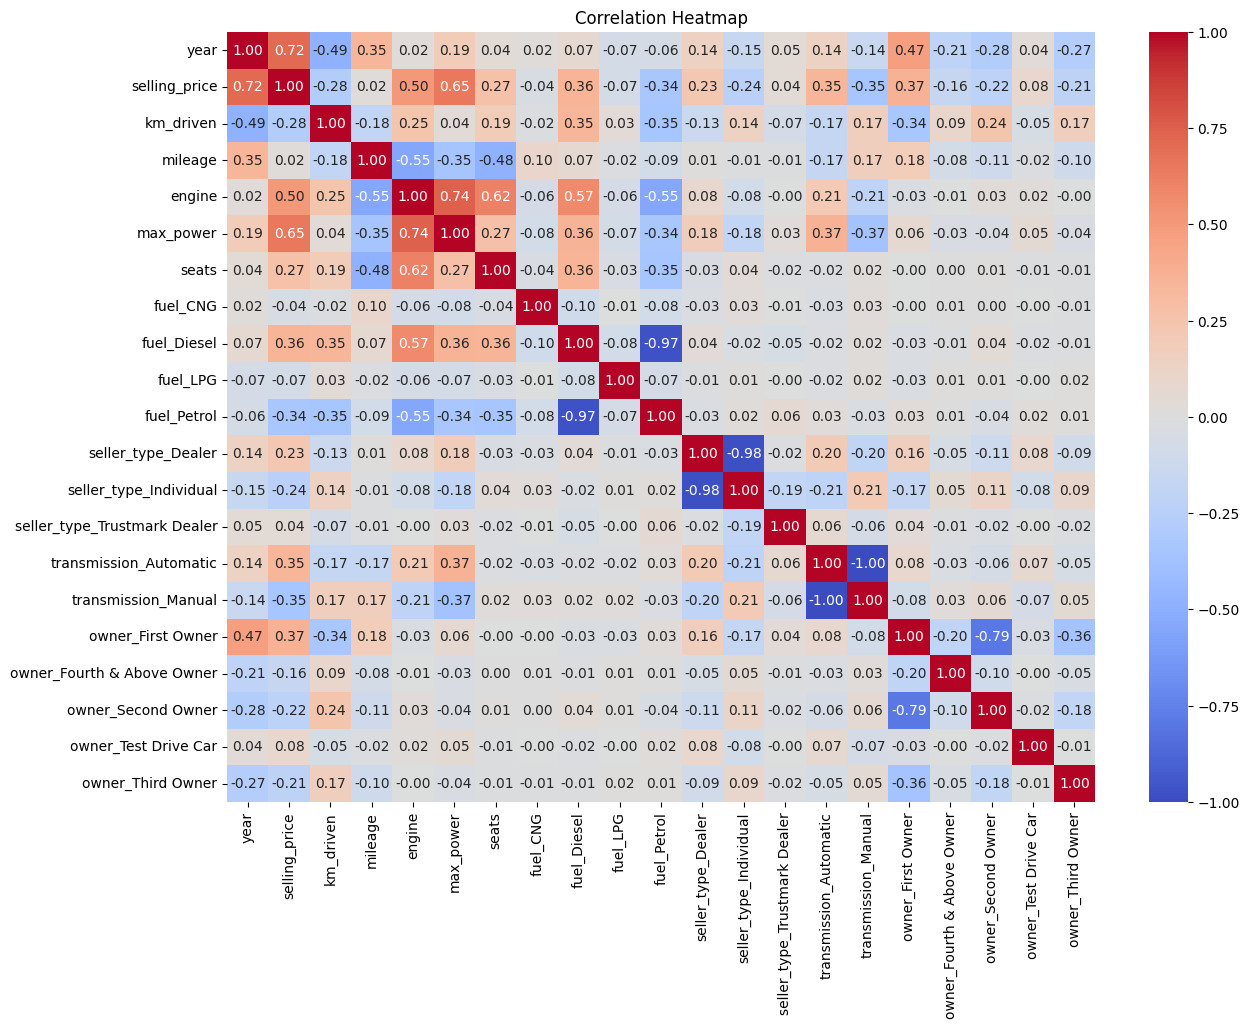

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [123]:
threshold = 0.35
corr_with_price = df.corr(numeric_only=True)['selling_price']
selected_features = corr_with_price[corr_with_price.abs() > threshold].index.tolist()
selected_features.remove('selling_price')   # خود ستون هدف را از لیست ویژگی‌ها حذف کنید

print(selected_features)

['year', 'engine', 'max_power', 'fuel_Diesel', 'owner_First Owner']


In [129]:
from sklearn.model_selection import train_test_split

# فرض: selected_features از قبل آماده است (همان لیستی که با آستانه همبستگی ساختیم)
X = df[selected_features]
y_reg = df['selling_price']   # هدف برای رگرسیون‌ها (پیوسته)

X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

In [130]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# فقط یک ویژگی (قوی‌ترین همبستگی: year)
X_train_simple = X_train[['year']]
X_test_simple = X_test[['year']]

simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train)

y_pred_simple = simple_model.predict(X_test_simple)

print("Simple Linear Regression:")
print("R2:", r2_score(y_test, y_pred_simple))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_simple)))

Simple Linear Regression:
R2: 0.5363127708526099
RMSE: 0.08760635925099045


In [126]:
X_train_bi = X_train[['year', 'max_power']]
X_test_bi = X_test[['year', 'max_power']]

bi_model = LinearRegression()
bi_model.fit(X_train_bi, y_train)

y_pred_bi = bi_model.predict(X_test_bi)

print("Bivariate Regression:")
print("R2:", r2_score(y_test, y_pred_bi))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_bi)))

Bivariate Regression:
R2: 0.7822839000964965
RMSE: 0.060029999240346625


In [127]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

poly_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)
poly_model.fit(X_train, y_train)

y_pred_poly = poly_model.predict(X_test)

print("Polynomial Regression (degree=2):")
print("R2:", r2_score(y_test, y_pred_poly))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly)))

Polynomial Regression (degree=2):
R2: 0.8327605688554245
RMSE: 0.05261292000803448


In [128]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.model_selection import GridSearchCV

# ---- Ridge ----
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train, y_train)

print("Ridge - Best alpha:", ridge_grid.best_params_)
print("Ridge - Best CV R2:", ridge_grid.best_score_)
y_pred_ridge = ridge_grid.predict(X_test)
print("Ridge - Test R2:", r2_score(y_test, y_pred_ridge))

# ---- Lasso ----
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
lasso_grid = GridSearchCV(Lasso(max_iter=5000), lasso_params, cv=5, scoring='r2')
lasso_grid.fit(X_train, y_train)

print("\nLasso - Best alpha:", lasso_grid.best_params_)
print("Lasso - Best CV R2:", lasso_grid.best_score_)
y_pred_lasso = lasso_grid.predict(X_test)
print("Lasso - Test R2:", r2_score(y_test, y_pred_lasso))

# ---- ElasticNet ----
elastic_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
elastic_grid = GridSearchCV(ElasticNet(max_iter=5000), elastic_params, cv=5, scoring='r2')
elastic_grid.fit(X_train, y_train)

print("\nElasticNet - Best params:", elastic_grid.best_params_)
print("ElasticNet - Best CV R2:", elastic_grid.best_score_)
y_pred_elastic = elastic_grid.predict(X_test)
print("ElasticNet - Test R2:", r2_score(y_test, y_pred_elastic))

Ridge - Best alpha: {'alpha': 0.01}
Ridge - Best CV R2: 0.8230484566768718
Ridge - Test R2: 0.8103865829622082

Lasso - Best alpha: {'alpha': 0.001}
Lasso - Best CV R2: 0.8192816169911484
Lasso - Test R2: 0.8091313145650898

ElasticNet - Best params: {'alpha': 0.001, 'l1_ratio': 0.1}
ElasticNet - Best CV R2: 0.8222080446654253
ElasticNet - Test R2: 0.8105246586131717
